In [1]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.model_selection import KFold
import matplotlib.pyplot as plt
from torch.optim.lr_scheduler import CosineAnnealingWarmRestarts
from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm.auto import tqdm
import os
import pickle
import math # Transformer
from datetime import datetime

In [2]:
# Search GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: NVIDIA L40S


In [3]:
def normalize_quaternions(quaternion_features):
    """
    Normalise quaternion features to unit length: w²+x²+y²+z²=1
    """
    import numpy as np

    norms = np.linalg.norm(quaternion_features, axis=1, keepdims=True)

    norms[norms == 0] = 1.0

    normalized_quaternions = quaternion_features / norms

    if __debug__:
        verification_norms = np.linalg.norm(normalized_quaternions, axis=1)
        assert np.allclose(verification_norms, 1.0, atol=1e-6), \
            "Quaternion normalisation failed"

    return normalized_quaternions

In [4]:
file_path_CoM_Kabsch = '/srv/scratch/z5548879/VIVIAN_Dataset_V1/vive_vicon_CoM_data.csv'

# Load Kabsch data (primary dataset)
data_kabsch = pd.read_csv(file_path_CoM_Kabsch)

hip_thickness = {
    'HW3-001': 228.0,
    'HW3-002': 204.0,
    'HW3-003': 233.0,
    'HW3-004': 195.0,  # remove 4
    'HW3-006': 224.0,  # remove 5
    'HW3-007': 239.0,
    'HW3-008': 218.0,
    'HW3-009': 222.0,
    'HW3-010': 191.0
}

# Filter Kabsch data
print("Original Kabsch data shape:", data_kabsch.shape)
data_kabsch = data_kabsch[data_kabsch.iloc[:, 0] != 'HW3-004']  # removed 4
data_kabsch = data_kabsch[data_kabsch.iloc[:, 0] != 'HW3-005']  # removed 5
data_kabsch = data_kabsch[~((data_kabsch.iloc[:, 0] == 'HW3-010') & (data_kabsch.iloc[:, 1] == 2.0))]
print("Filtered Kabsch data shape:", data_kabsch.shape)

# Re-sort data to ensure ordering by participant and timestamp
data_kabsch = data_kabsch.sort_values(['participant_id', 'time_stamp'] if 'participant_id' in data_kabsch.columns and 'time_stamp' in data_kabsch.columns
                       else [data_kabsch.columns[0], data_kabsch.columns[4]])

data_kabsch_numpy = data_kabsch.to_numpy()

# Extract basic info from Kabsch data
participant_id = data_kabsch_numpy[:, 0]  # 8 participants
speed          = data_kabsch_numpy[:, 1]  # 0.5 1.0 1.5 2.0 m/s
direction      = data_kabsch_numpy[:, 3]  # XYZ

# Extract position data -- separated by direction (VIVE as input, Vicon as target)
vicon_data = data_kabsch_numpy[:, 6]  # Vicon data (target)
vive_data  = data_kabsch_numpy[:, 7]  # VIVE data (input)

# Extract XYZ positional features
def extract_xyz_features(position_data, participant_ids, speed_data, direction_data):
    """Extract XYZ positional features for each participant at each speed"""
    unique_participants = np.unique(participant_ids)
    unique_speeds = np.unique(speed_data)

    # Count total data points (number of time points per participant-speed combination)
    total_points = 0
    for participant in unique_participants:
        for speed_val in unique_speeds:
            mask = (participant_ids == participant) & (speed_data == speed_val)
            if np.any(mask):
                # Use the X-direction point count as the reference
                x_mask = mask & (direction_data == 'X')
                total_points += np.sum(x_mask)

    # Initialise feature matrices
    xyz_features          = np.zeros((total_points, 3))   # X, Y, Z
    xyz_spatial_magnitude = np.zeros(total_points)         # sqrt(x^2+y^2+z^2)
    feature_participant_ids = []
    feature_speeds          = []

    current_idx = 0

    for participant in unique_participants:
        for speed_val in unique_speeds:
            # Retrieve data for the current participant and speed
            base_mask = (participant_ids == participant) & (speed_data == speed_val)

            if np.any(base_mask):
                x_mask = base_mask & (direction_data == 'X')
                y_mask = base_mask & (direction_data == 'Y')
                z_mask = base_mask & (direction_data == 'Z')

                x_indices = np.where(x_mask)[0]
                y_indices = np.where(y_mask)[0]
                z_indices = np.where(z_mask)[0]

                # Ensure XYZ arrays have consistent lengths
                min_length = min(len(x_indices), len(y_indices), len(z_indices))

                if min_length > 0:
                    x_values = np.array(position_data[x_indices[:min_length]], dtype=float)
                    y_values = np.array(position_data[y_indices[:min_length]], dtype=float)
                    z_values = np.array(position_data[z_indices[:min_length]], dtype=float)

                    # Store XYZ features
                    end_idx = current_idx + min_length
                    xyz_features[current_idx:end_idx, 0] = x_values  # X
                    xyz_features[current_idx:end_idx, 1] = y_values  # Y
                    xyz_features[current_idx:end_idx, 2] = z_values  # Z

                    # Compute spatial magnitude
                    spatial_magnitude = np.sqrt(x_values**2 + y_values**2 + z_values**2)
                    xyz_spatial_magnitude[current_idx:end_idx] = spatial_magnitude

                    # Record corresponding participant and speed metadata
                    for _ in range(min_length):
                        feature_participant_ids.append(participant)
                        feature_speeds.append(speed_val)

                    current_idx = end_idx

    # Trim to the actually populated portion
    xyz_features          = xyz_features[:current_idx]
    xyz_spatial_magnitude = xyz_spatial_magnitude[:current_idx]

    return xyz_features, xyz_spatial_magnitude, np.array(feature_participant_ids), np.array(feature_speeds)


print("Extracting VIVE XYZ positional features...")
vive_xyz, vive_spatial_mag, vive_participants, vive_speeds = extract_xyz_features(
    vive_data, participant_id, speed, direction)

print("Extracting Vicon XYZ positional features...")
vicon_xyz, vicon_spatial_mag, vicon_participants, vicon_speeds = extract_xyz_features(
    vicon_data, participant_id, speed, direction)

print("VIVE XYZ feature shape :", vive_xyz.shape)
print("VIVE spatial magnitude shape:", vive_spatial_mag.shape)
print("Vicon XYZ feature shape:", vicon_xyz.shape)
print("Vicon spatial magnitude shape:", vicon_spatial_mag.shape)

# Align data lengths
min_length = min(len(vive_xyz), len(vicon_xyz))
print(f"Aligned data length: {min_length}")

# Truncate to the same length
vive_xyz          = vive_xyz[:min_length]
vive_spatial_mag  = vive_spatial_mag[:min_length]
vicon_xyz         = vicon_xyz[:min_length]
vicon_spatial_mag = vicon_spatial_mag[:min_length]
aligned_participants = vive_participants[:min_length]
aligned_speeds       = vive_speeds[:min_length]

# Append hip thickness information
hip_thickness_values = np.array([hip_thickness[pid] for pid in aligned_participants])

# Process categorical features
participant_encoder   = LabelEncoder()
participant_encoded   = participant_encoder.fit_transform(aligned_participants)
participant_normalised = participant_encoded / (len(np.unique(participant_encoded)) - 1)

# Normalise all numerical features
scalers = {}

# VIVE XYZ positional features (3-dimensional)
scalers['vive_xyz'] = StandardScaler()
vive_xyz_scaled = scalers['vive_xyz'].fit_transform(vive_xyz)

# VIVE spatial magnitude feature (1-dimensional)
scalers['vive_spatial'] = StandardScaler()
vive_spatial_scaled = scalers['vive_spatial'].fit_transform(vive_spatial_mag.reshape(-1, 1))

# Vicon target variables (3-dimensional)
scalers['vicon_xyz'] = StandardScaler()
vicon_xyz_scaled = scalers['vicon_xyz'].fit_transform(vicon_xyz)

# Vicon spatial magnitude feature (1-dimensional)
scalers['vicon_spatial'] = StandardScaler()
vicon_spatial_scaled = scalers['vicon_spatial'].fit_transform(vicon_spatial_mag.reshape(-1, 1))

# Other features
scalers['speed']         = StandardScaler()
scalers['hip_thickness'] = StandardScaler()

speed_scaled         = scalers['speed'].fit_transform(aligned_speeds.reshape(-1, 1))
hip_thickness_scaled = scalers['hip_thickness'].fit_transform(hip_thickness_values.reshape(-1, 1))

# Assemble all features (quaternions excluded)
additional_features = np.hstack([
    speed_scaled,                           # 1 feature: gait speed
    hip_thickness_scaled,                   # 1 feature: hip thickness
    vive_spatial_scaled,                    # 1 feature: VIVE spatial magnitude
    vive_xyz_scaled,                        # 3 features: VIVE XYZ coordinates
])

# Generate sequence data
seq_length = 10

def create_sequences_with_xyz_features(xyz_input, additional_feats, xyz_target, participant_ids, seq_length=10):
    """Create sequence data incorporating XYZ features"""
    x_time, x_feat, y, seq_participant_ids = [], [], [], []

    unique_participants = np.unique(participant_ids)

    for participant in unique_participants:
        participant_mask    = participant_ids == participant
        participant_indices = np.where(participant_mask)[0]

        # Build sequences for each participant
        step_size = 1
        for i in range(0, len(participant_indices) - seq_length, step_size):
            if i + seq_length < len(participant_indices):
                start_idx  = participant_indices[i]
                end_idx    = participant_indices[i + seq_length]
                target_idx = participant_indices[i + seq_length]

                x_time.append(xyz_input[start_idx:end_idx])  # XYZ time series
                x_feat.append(additional_feats[target_idx])   # Additional features
                y.append(xyz_target[target_idx])              # XYZ target
                seq_participant_ids.append(participant_ids[target_idx])

    return np.array(x_time), np.array(x_feat), np.array(y), np.array(seq_participant_ids)


print("Generating XYZ sequence data...")
X_time, X_feat, y, seq_participant_ids = create_sequences_with_xyz_features(
    vive_xyz_scaled, additional_features, vicon_xyz_scaled, aligned_participants, seq_length
)

print("Final training data shapes:")
print("  X_time -- VIVE XYZ time series :", X_time.shape)
print("  X_feat -- additional features  :", X_feat.shape)
print("  y      -- Vicon XYZ target     :", y.shape)
print("  Total sequences               :", len(seq_participant_ids))

Original Kabsch data shape: (525000, 8)
Filtered Kabsch data shape: (465000, 8)
Extracting VIVE XYZ positional features...
Extracting Vicon XYZ positional features...
VIVE XYZ feature shape : (155000, 3)
VIVE spatial magnitude shape: (155000,)
Vicon XYZ feature shape: (155000, 3)
Vicon spatial magnitude shape: (155000,)
Aligned data length: 155000
Generating XYZ sequence data...
Final training data shapes:
  X_time -- VIVE XYZ time series : (154920, 10, 3)
  X_feat -- additional features  : (154920, 6)
  y      -- Vicon XYZ target     : (154920, 3)
  Total sequences               : 154920


In [5]:
class EarlyStopping:
    def __init__(self, patience=8, min_delta=1e-5, restore_best_weights=True):
        self.patience = patience
        self.min_delta = min_delta
        self.restore_best_weights = restore_best_weights
        self.best_loss = None
        self.counter = 0
        self.best_weights = None
        
    def __call__(self, val_loss, model):
        if self.best_loss is None:
            self.best_loss = val_loss
            self.save_checkpoint(model)
        elif val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            self.save_checkpoint(model)
        else:
            self.counter += 1
            
        if self.counter >= self.patience:
            if self.restore_best_weights:
                model.load_state_dict(self.best_weights)
            return True
        return False
    
    def save_checkpoint(self, model):
        self.best_weights = model.state_dict().copy()

In [6]:
class PositionalEncoding(nn.Module):
    """ Add Transformer location information"""
    def __init__(self, d_model, max_len=5000, batch_first=True):
        super(PositionalEncoding, self).__init__()
        self.batch_first = batch_first
        
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * 
                           (-math.log(10000.0) / d_model))
        
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        
        if batch_first:
            # (1, max_len, d_model) for batch_first=True
            pe = pe.unsqueeze(0)
        else:
            # (max_len, 1, d_model) for batch_first=False
            pe = pe.unsqueeze(1)
            
        self.register_buffer('pe', pe)
        
    def forward(self, x):
        if self.batch_first:
            # x shape: (batch_size, seq_len, d_model)
            seq_len = x.size(1)
            return x + self.pe[:, :seq_len, :]
        else:
            # x shape: (seq_len, batch_size, d_model)
            seq_len = x.size(0)
            return x + self.pe[:seq_len, :, :]

In [7]:
class TransformerBlock(nn.Module):
    """ Single Transformer block with Pre-LayerNorm architecture"""
    def __init__(self, d_model, nhead, dim_feedforward, dropout=0.01):
        super(TransformerBlock, self).__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.linear1 = nn.Linear(d_model, dim_feedforward)
        self.dropout = nn.Dropout(dropout)
        self.linear2 = nn.Linear(dim_feedforward, d_model)
        
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        
        self._init_weights()
        
    def _init_weights(self):
        """Initialize weights using Xavier uniform initialization"""
        nn.init.xavier_uniform_(self.linear1.weight)
        nn.init.xavier_uniform_(self.linear2.weight)
        nn.init.constant_(self.linear1.bias, 0)
        nn.init.constant_(self.linear2.bias, 0)
        
    def forward(self, src, src_mask=None, src_key_padding_mask=None, return_attention=False):
        # Pre-LayerNorm
        # Self-attention
        norm_src = self.norm1(src)
        src2, attention_weights = self.self_attn(norm_src, norm_src, norm_src, 
                                               attn_mask=src_mask,
                                               key_padding_mask=src_key_padding_mask)
        src = src + self.dropout1(src2)
        
        # Feed forward
        norm_src = self.norm2(src)
        src2 = self.linear2(self.dropout(torch.relu(self.linear1(norm_src))))
        src = src + self.dropout2(src2)
        
        if return_attention:
            return src, attention_weights
        return src

In [8]:
class AdvancedTransformerModel(nn.Module):
    def __init__(self, seq_length, num_features=6, hidden_dim=128, dropout_rate=0.1,
                 nhead=8, num_transformer_layers=3, dim_feedforward=512):
        super(AdvancedTransformerModel, self).__init__()

        if hidden_dim % nhead != 0:
            hidden_dim = ((hidden_dim // nhead) + 1) * nhead
            print(f"Adjusted hidden_dim to {hidden_dim} to be compatible with multi-head attention")

        self.hidden_dim = hidden_dim
        self.seq_length = seq_length

        self.conv1 = nn.Sequential(
            nn.Conv1d(3, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8, 64),
            nn.ReLU()
        )

        self.conv_ms1 = nn.Conv1d(64, 24, kernel_size=3,  padding=1)   # Short-term:      30 ms
        self.conv_ms2 = nn.Conv1d(64, 24, kernel_size=7,  padding=3)   # Short-mid-term:  70 ms
        self.conv_ms3 = nn.Conv1d(64, 24, kernel_size=15, padding=7)   # Mid-term:       150 ms
        self.conv_ms4 = nn.Conv1d(64, 24, kernel_size=31, padding=15)  # Long-term:      310 ms  <- new

        self.conv2 = nn.Sequential(
            nn.GroupNorm(12, 96),
            nn.ReLU(),
            nn.Conv1d(96, 128, kernel_size=3, padding=1),
            nn.GroupNorm(16, 128),
            nn.ReLU()
        )

        self.gradient_conv = nn.Sequential(
            nn.Conv1d(6, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.Tanh(),
            nn.Conv1d(32, 32, kernel_size=3, padding=1),
            nn.GroupNorm(4, 32),
            nn.Tanh()
        )

        self.dropout_cnn = nn.Dropout(dropout_rate)

        self.cnn_projection = nn.Linear(160, hidden_dim)

        # ====================================================================
        # Transformer
        # ====================================================================
        self.pos_encoder = PositionalEncoding(hidden_dim, max_len=seq_length, batch_first=True)

        self.transformer_layers = nn.ModuleList([
            TransformerBlock(hidden_dim, nhead, dim_feedforward, dropout_rate)
            for _ in range(num_transformer_layers)
        ])

        self.global_attention = nn.MultiheadAttention(
            embed_dim=hidden_dim,
            num_heads=nhead,
            batch_first=True
        )

        self.global_query = nn.Parameter(torch.randn(1, 1, hidden_dim))

        self.feat_fc1 = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.LayerNorm(64),
            nn.ReLU()
        )

        self.feat_fc2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU()
        )

        self.feat_res = nn.Sequential(
            nn.Linear(num_features, 128),
            nn.LayerNorm(128)
        )

        self.feature_fusion = nn.Sequential(
            nn.Linear(hidden_dim + 128, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 3)
        )

        self._init_weights()

    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Conv1d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')

    def forward(self, x_time, x_feat, return_attention=False):
        batch_size = x_time.size(0)

        x_time_input = x_time.permute(0, 2, 1)   # [batch, 3, seq_len]

        x = self.conv1(x_time_input)              # [batch, 64, seq_len]

        x_ms1 = self.conv_ms1(x)                 # [batch, 24, seq_len]
        x_ms2 = self.conv_ms2(x)                 # [batch, 24, seq_len]
        x_ms3 = self.conv_ms3(x)                 # [batch, 24, seq_len]
        x_ms4 = self.conv_ms4(x)                 # [batch, 24, seq_len]  <- new
        x_multi_scale = torch.cat([x_ms1, x_ms2, x_ms3, x_ms4], dim=1)  # [batch, 96, seq_len]

        x = self.conv2(x_multi_scale)             # [batch, 128, seq_len]

        # First-order finite difference (velocity)
        x_grad1 = torch.diff(x_time_input, dim=2,
                              prepend=x_time_input[:, :, :1])  # [batch, 3, seq_len]

        # Second-order finite difference (acceleration)
        x_grad2 = torch.diff(x_grad1, dim=2,
                              prepend=x_grad1[:, :, :1])        # [batch, 3, seq_len]

        # Concatenate first- and second-order gradients
        x_grad_combined = torch.cat([x_grad1, x_grad2], dim=1)  # [batch, 6, seq_len]

        x_grad = self.gradient_conv(x_grad_combined)              # [batch, 32, seq_len]

        # Merge CNN features and gradient features
        x_combined = torch.cat([x, x_grad], dim=1)   # [batch, 160, seq_len]
        x_combined = self.dropout_cnn(x_combined)

        x_combined = x_combined.permute(0, 2, 1)     # [batch, seq_len, 160]
        x_combined = self.cnn_projection(x_combined)  # [batch, seq_len, hidden_dim]
        x_combined = self.pos_encoder(x_combined)

        attention_weights_list = []
        for transformer_layer in self.transformer_layers:
            if return_attention:
                x_combined, attention_weights = transformer_layer(x_combined, return_attention=True)
                attention_weights_list.append(attention_weights)
            else:
                x_combined = transformer_layer(x_combined, return_attention=False)

        # Global attention pooling
        global_query = self.global_query.expand(batch_size, -1, -1)
        context, global_attention_weights = self.global_attention(
            global_query, x_combined, x_combined
        )
        context = context.squeeze(1)              # [batch, hidden_dim]

        feat_out      = self.feat_fc1(x_feat)
        feat_out      = self.feat_fc2(feat_out)
        feat_residual = self.feat_res(x_feat)
        feat_out      = feat_out + feat_residual

        combined = torch.cat([context, feat_out], dim=1)
        fused    = self.feature_fusion(combined)
        residual = self.classifier(fused)

        # Residual prediction: offset from the last observed VIVE frame
        vive_last_frame = x_time[:, -1, :]
        output = vive_last_frame + residual

        if return_attention:
            return output, {
                'transformer_attention': attention_weights_list,
                'global_attention':      global_attention_weights
            }
        else:
            return output

model = AdvancedTransformerModel(seq_length, num_features=7).to(device)
print(model)

AdvancedTransformerModel(
  (conv1): Sequential(
    (0): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): GroupNorm(8, 64, eps=1e-05, affine=True)
    (5): ReLU()
  )
  (conv_ms1): Conv1d(64, 24, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv_ms2): Conv1d(64, 24, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv_ms3): Conv1d(64, 24, kernel_size=(15,), stride=(1,), padding=(7,))
  (conv_ms4): Conv1d(64, 24, kernel_size=(31,), stride=(1,), padding=(15,))
  (conv2): Sequential(
    (0): GroupNorm(12, 96, eps=1e-05, affine=True)
    (1): ReLU()
    (2): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): GroupNorm(16, 128, eps=1e-05, affine=True)
    (4): ReLU()
  )
  (gradient_conv): Sequential(
    (0): Conv1d(6, 32, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(4, 32, eps=1e-05, affine=True

In [9]:
class AblationTransformerModel(nn.Module):
    def __init__(self, seq_length, num_features=6, hidden_dim=128, dropout_rate=0.01,
                 nhead=8, num_transformer_layers=3, dim_feedforward=512,
                 # Ablation experiment parameters
                 use_multi_scale=True, use_gradient_features=True, use_positional_encoding=True,
                 use_global_attention=True, use_residual_connection=True):
        super(AblationTransformerModel, self).__init__()
        
        if hidden_dim % nhead != 0:
            hidden_dim = ((hidden_dim // nhead) + 1) * nhead
        
        self.hidden_dim = hidden_dim
        self.seq_length = seq_length
        self.use_multi_scale = use_multi_scale
        self.use_gradient_features = use_gradient_features
        #self.use_positional_encoding = use_positional_encoding
        self.use_global_attention = use_global_attention
        self.use_residual_connection = use_residual_connection
        
        # Basic CNN
        self.conv1 = nn.Sequential(
            nn.Conv1d(1, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8,64),
            nn.ReLU(),
            nn.Conv1d(64, 64, kernel_size=3, padding=1),
            nn.GroupNorm(8,64),
            nn.ReLU()
        )
        
        # Multi-scale convolution (Ablation component 1)
        if self.use_multi_scale:
            self.conv_ms1 = nn.Conv1d(64, 32, kernel_size=3, padding=1)
            self.conv_ms2 = nn.Conv1d(64, 32, kernel_size=5, padding=2)
            self.conv_ms3 = nn.Conv1d(64, 32, kernel_size=7, padding=3)
            conv2_input_channels = 96
        else:
            conv2_input_channels = 64
            
        self.conv2 = nn.Sequential(
            nn.GroupNorm(conv2_input_channels//8, conv2_input_channels),
            nn.ReLU(),
            nn.Conv1d(conv2_input_channels, 128, kernel_size=3, padding=1),
            nn.GroupNorm(16,128),
            nn.ReLU()
        )
        
        # Gradient features (Ablation component 2)
        if self.use_gradient_features:
            self.gradient_conv = nn.Sequential(
                nn.Conv1d(3, 32, kernel_size=3, padding=1),
                nn.GroupNorm(4, 32),
                nn.Tanh(),
                nn.Conv1d(32, 32, kernel_size=3, padding=1),
                nn.GroupNorm(4, 32),
                nn.Tanh()
            )
            cnn_output_dim = 160  # 128 + 32
        else:
            cnn_output_dim = 128
            
        self.dropout_cnn = nn.Dropout(dropout_rate * 0.2)
        self.cnn_projection = nn.Linear(cnn_output_dim, hidden_dim)
        
        # Positional encoding (Ablation component 3)
        #if self.use_positional_encoding:
            #self.pos_encoder = PositionalEncoding(hidden_dim, max_len=seq_length, batch_first=True)
        
        # Transformer layers
        self.transformer_layers = nn.ModuleList([
            TransformerBlock(hidden_dim, nhead, dim_feedforward, dropout_rate * 0.2)
            for _ in range(num_transformer_layers)
        ])
        
        # Global attention (Ablation component 4)
        if self.use_global_attention:
            self.global_attention = nn.MultiheadAttention(
                embed_dim=hidden_dim, 
                num_heads=nhead, 
                batch_first=True
            )
            self.global_query = nn.Parameter(torch.randn(1, 1, hidden_dim))
        
        # Feature processing network
        self.feat_fc1 = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
        )
        
        self.feat_fc2 = nn.Sequential(
            nn.Linear(64, 128),
            nn.LayerNorm(128),
            nn.ReLU(),
        )
        
        # Residual connection (Ablation component 5)
        if self.use_residual_connection:
            self.feat_res = nn.Sequential(
                nn.Linear(num_features, 128),
                nn.LayerNorm(128)
            )
        
        self.feature_fusion = nn.Sequential(
            nn.Linear(hidden_dim + 128, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.ReLU(),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU()
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.LayerNorm(hidden_dim // 2),
            nn.ReLU(),
            nn.Linear(hidden_dim // 2, 1)
        )
        
        self._init_weights()
        
    def _init_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Conv1d):
                nn.init.kaiming_normal_(module.weight, mode='fan_out', nonlinearity='relu')
        
    def forward(self, x_time, x_feat, return_attention=False):
        batch_size = x_time.size(0)
        x_time_input = x_time.permute(0, 2, 1)
        
        # Basic CNN features
        x = self.conv1(x_time_input)
        
        # Multi-scale features (Ablation component 1)
        if self.use_multi_scale:
            x_ms1 = self.conv_ms1(x)
            x_ms2 = self.conv_ms2(x)
            x_ms3 = self.conv_ms3(x)
            x = torch.cat([x_ms1, x_ms2, x_ms3], dim=1)
        
        x = self.conv2(x)
        
        # Gradient features (Ablation component 2)
        if self.use_gradient_features:
            x_grad_input = torch.diff(x_time_input, dim=2, prepend=x_time_input[:, :, :1])
            x_grad = self.gradient_conv(x_grad_input)
            x_combined = torch.cat([x, x_grad], dim=1)
        else:
            x_combined = x
            
        x_combined = self.dropout_cnn(x_combined)
        x_combined = x_combined.permute(0, 2, 1)
        x_combined = self.cnn_projection(x_combined)
        
        # Positional encoding (Ablation component 3)
        #if self.use_positional_encoding:
        #    x_combined = self.pos_encoder(x_combined)
        
        # Store attention weights if requested
        attention_weights = []
        
        # Transformer layers
        for transformer_layer in self.transformer_layers:
            if return_attention and hasattr(transformer_layer, 'forward'):
                # Try to get attention from transformer layer if it supports it
                try:
                    x_combined, layer_attention = transformer_layer(x_combined, return_attention=True)
                    attention_weights.append(layer_attention)
                except:
                    # Fallback if transformer layer doesn't support attention return
                    x_combined = transformer_layer(x_combined)
                    attention_weights.append(None)
            else:
                x_combined = transformer_layer(x_combined)
        
        # Global attention pooling (Ablation component 4)
        global_attention_weights = None
        if self.use_global_attention:
            global_query = self.global_query.expand(batch_size, -1, -1)
            context, global_attention_weights = self.global_attention(global_query, x_combined, x_combined)
            context = context.squeeze(1)
        else:
            context = torch.mean(x_combined, dim=1)  # Simple average pooling
        
        # Feature processing
        feat_out = self.feat_fc1(x_feat)
        feat_out = self.feat_fc2(feat_out)
        
        # Residual connection (Ablation component 5)
        if self.use_residual_connection:
            feat_residual = self.feat_res(x_feat)
            feat_out = feat_out + feat_residual
        
        # Feature fusion and prediction
        combined = torch.cat([context, feat_out], dim=1)
        fused_features = self.feature_fusion(combined)
        output = self.classifier(fused_features)
        
        if return_attention:
            attention_info = {
                'transformer_attention': attention_weights,
                'global_attention': global_attention_weights
            }
            return output, attention_info
        else:
            return output

# Ablation experiment configurations
ablation_configs = {
    'Full Model': {
        'use_multi_scale': True,
        'use_gradient_features': True,
        'use_positional_encoding': True,
        'use_global_attention': True,
        'use_residual_connection': True
    },
    'No Multi-Scale': {
        'use_multi_scale': False,
        'use_gradient_features': True,
        'use_positional_encoding': True,
        'use_global_attention': True,
        'use_residual_connection': True
    },
    'No Gradient Features': {
        'use_multi_scale': True,
        'use_gradient_features': False,
        'use_positional_encoding': True,
        'use_global_attention': True,
        'use_residual_connection': True
    },
    'No Positional Encoding': {
        'use_multi_scale': True,
        'use_gradient_features': True,
        'use_positional_encoding': False,
        'use_global_attention': True,
        'use_residual_connection': True
    },
    'No Global Attention': {
        'use_multi_scale': True,
        'use_gradient_features': True,
        'use_positional_encoding': True,
        'use_global_attention': False,
        'use_residual_connection': True
    },
    'No Residual Connection': {
        'use_multi_scale': True,
        'use_gradient_features': True,
        'use_positional_encoding': True,
        'use_global_attention': True,
        'use_residual_connection': False
    },
    'Minimal Model': {
        'use_multi_scale': False,
        'use_gradient_features': False,
        'use_positional_encoding': False,
        'use_global_attention': False,
        'use_residual_connection': False
    }
}

def run_ablation_study():
    """Run ablation experiment"""
    print("Starting Ablation Study...")
    print("="*60)
    
    ablation_results = {}
    
    # Select one participant as validation set for quick ablation experiment
    val_participant = unique_participants[0]  # Use first participant
    
    val_indices = np.where(seq_participant_ids == val_participant)[0]
    train_indices = np.where(seq_participant_ids != val_participant)[0]
    
    X_time_train, X_time_val = X_time[train_indices], X_time[val_indices]
    X_feat_train, X_feat_val = X_feat[train_indices], X_feat[val_indices]
    y_train, y_val = y[train_indices], y[val_indices]
    
    train_dataset = TensorDataset(
        torch.tensor(X_time_train, dtype=torch.float32),
        torch.tensor(X_feat_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_time_val, dtype=torch.float32),
        torch.tensor(X_feat_val, dtype=torch.float32),
        torch.tensor(y_val, dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, pin_memory=True)
    
    for config_name, config in ablation_configs.items():
        print(f"\nTesting Configuration: {config_name}")
        print("-" * 40)
        
        # Create model
        model = AblationTransformerModel(
            seq_length, 
            num_features=X_feat.shape[1],
            **config
        ).to(device)
        
        # Training setup
        mse_loss = nn.MSELoss()
        l1_loss = nn.L1Loss()
        criterion = lambda output, target: mse_loss(output, target) + 0.02 * l1_loss(output, target)

        optimiser = optim.AdamW(model.parameters(), lr=0.0002, weight_decay=5e-4)
        scheduler = ReduceLROnPlateau(optimiser, mode='min', factor=0.7, patience=4)
        
        # Simplified training (reduce epochs to speed up ablation experiment)
        model, history = train_model(model, train_loader, val_loader, criterion, optimiser, scheduler, epochs=20, patience=20)
        
        # Evaluation
        val_loss, predictions, actuals = evaluate_model(model, val_loader, criterion)
        
        ablation_results[config_name] = {
            'val_loss': val_loss,
            'final_train_loss': history['train_loss'][-1],
            'config': config
        }
        
        print(f"{config_name}: Val Loss = {val_loss:.4f}")
        
        # Clean GPU memory
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Display results
    print("\n" + "="*60)
    print("ABLATION STUDY RESULTS")
    print("="*60)
    
    # Sort by validation loss
    sorted_results = sorted(ablation_results.items(), key=lambda x: x[1]['val_loss'])
    
    for i, (config_name, results) in enumerate(sorted_results):
        print(f"{i+1:2d}. {config_name:20s} | Val Loss: {results['val_loss']:.4f}")
    
    # Calculate performance change relative to Full Model
    full_model_loss = ablation_results['Full Model']['val_loss']
    print(f"\nPerformance Impact (vs Full Model):")
    print("-" * 40)
    
    for config_name, results in ablation_results.items():
        if config_name != 'Full Model':
            impact = ((results['val_loss'] - full_model_loss) / full_model_loss) * 100
            print(f"{config_name:20s}: {impact:+6.2f}%")
    
    return ablation_results

In [10]:
def train_model(model, train_loader, val_loader, criterion, optimiser, scheduler, epochs=50, patience=8):
    best_val_loss = float('inf')
    best_model = None
    history = {'train_loss': [], 'val_loss': [],
               'train_loss_eval_mode': []
               }

    early_stopping = EarlyStopping(patience=patience, restore_best_weights=True)

    # Gradient accumulation settings
    accum_steps = 4  # Update weights every 4 batches

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("---" * 30)  # Progress bar separator

        # Training phase
        model.train()
        train_predictions = []
        train_actuals     = []
        train_losses      = []

        optimiser.zero_grad()  # Zero gradients at start of epoch

        # Create progress bar for training
        train_pbar = tqdm(train_loader, desc="Training", leave=True)

        for i, (batch_X_time, batch_X_feat, batch_y) in enumerate(train_pbar):
            # Move data to device
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            batch_y      = batch_y.to(device)

            # Forward pass
            output = model(batch_X_time, batch_X_feat)

            # Compute raw loss (for logging and statistics)
            original_loss = criterion(output, batch_y)

            # Record raw loss for statistics
            train_losses.append(original_loss.item())

            # Scale loss for gradient accumulation
            scaled_loss = original_loss / accum_steps
            scaled_loss.backward()

            # Collect predictions and actuals for RMSE calculation (detach from graph)
            train_predictions.append(output.detach().cpu().numpy())
            train_actuals.append(batch_y.detach().cpu().numpy())

            # Update weights every accum_steps batches
            if (i + 1) % accum_steps == 0 or (i + 1) == len(train_loader):
                # Gradient clipping to prevent exploding gradients
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.5)
                optimiser.step()
                optimiser.zero_grad()

                # Clean up GPU memory
                if torch.cuda.is_available():
                    torch.cuda.empty_cache()

            # Update progress bar with raw loss
            train_pbar.set_postfix({"batch_loss": f"{original_loss.item():.4f}"})

            # Free up memory
            del batch_X_time, batch_X_feat, batch_y, output, original_loss, scaled_loss

        # Calculate training loss
        train_loss = np.mean(train_losses)
        history['train_loss'].append(train_loss)

        # Validation phase
        model.eval()
        val_predictions   = []
        val_actuals       = []
        train_eval_losses = []

        with torch.no_grad():
            train_eval_pbar = tqdm(train_loader, desc="Train Eval", leave=True)
            for batch_X_time, batch_X_feat, batch_y in train_eval_pbar:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                batch_y      = batch_y.to(device)

                output     = model(batch_X_time, batch_X_feat)
                batch_loss = criterion(output, batch_y).item()
                train_eval_losses.append(batch_loss)

                del batch_X_time, batch_X_feat, batch_y, output

        train_eval_loss = np.mean(train_eval_losses)
        history['train_loss_eval_mode'].append(train_eval_loss)

        val_losses = []
        # Create progress bar for validation
        val_pbar = tqdm(val_loader, desc="Validation", leave=True)

        with torch.no_grad():
            for batch_X_time, batch_X_feat, batch_y in val_pbar:
                # Move data to device
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                batch_y      = batch_y.to(device)

                output = model(batch_X_time, batch_X_feat)

                # Collect predictions and actuals for RMSE calculation
                val_predictions.append(output.cpu().numpy())
                val_actuals.append(batch_y.cpu().numpy())

                # Calculate loss for progress bar
                batch_loss = criterion(output, batch_y).item()
                val_losses.append(batch_loss)
                val_pbar.set_postfix({"batch_loss": f"{batch_loss:.4f}"})

                # Free up memory
                del batch_X_time, batch_X_feat, batch_y, output

        # Calculate validation loss
        val_loss = np.mean(val_losses)
        history['val_loss'].append(val_loss)

        # Update learning rate
        scheduler.step(val_loss)

        print(f"Epoch {epoch+1}/{epochs} completed - "
              f"Train Loss: {train_loss:.4f}, Train Eval: {train_eval_loss:.4f}, Val Loss: {val_loss:.4f}")

        for param_group in optimiser.param_groups:
            print(f"Current LR: {param_group['lr']}")

        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model    = model.state_dict().copy()
            print(f"New best model saved with Val Loss: {val_loss:.4f}")

        if early_stopping(val_loss, model):
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

        # Clean up GPU memory at end of epoch
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

    # Load best model
    model.load_state_dict(best_model)
    return model, history

In [11]:
# Function to evaluate the model
def evaluate_model(model, val_loader, criterion):
    model.eval()
    #val_loss = 0.0
    predictions = []
    actuals = []
    val_losses = []
    
    with torch.no_grad():
        for batch_X_time, batch_X_feat, batch_y in val_loader:
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            batch_y = batch_y.to(device)
            
            #output = model(batch_X_time, batch_X_feat)
            #output, attention_info = model(batch_X_time, batch_X_feat, return_attention=True)
            if hasattr(model, 'return_attention'):
                 output, attention_info = model(batch_X_time, batch_X_feat, return_attention=True)
            else:
                 output = model(batch_X_time, batch_X_feat)
                
            loss = criterion(output, batch_y)
            val_losses.append(loss.item())
            
            # Collect predictions and actuals for later analysis
            predictions.append(output.cpu().numpy())
            actuals.append(batch_y.cpu().numpy())
            
            # Free memory
            del batch_X_time, batch_X_feat, batch_y, output, loss
    
    # Convert lists to arrays
    predictions = np.vstack(predictions)
    actuals = np.vstack(actuals)
    
    # Calculate RMSE
    # avg_val_loss = val_losses / len(val_loader)
    avg_val_loss = np.mean(val_losses)
    
    return avg_val_loss, predictions, actuals

In [12]:
# ablation_results = run_ablation_study()

In [13]:
print("Starting Participant-based K-fold Cross Validation...")
unique_participants = np.unique(seq_participant_ids)
print(f"Available participants: {unique_participants}")

Starting Participant-based K-fold Cross Validation...
Available participants: ['HW3-001' 'HW3-002' 'HW3-003' 'HW3-006' 'HW3-007' 'HW3-008' 'HW3-009'
 'HW3-010']


In [14]:
num_folds = len(unique_participants)  # 8-fold
fold_rmse_scores = []
best_models      = []
all_histories    = []
batch_size       = 64

for fold, val_participant in enumerate(unique_participants):
    print(f"\nFold {fold+1}/{num_folds} - Validation Participant: {val_participant}")
    print("-" * 60)

    # Build training and validation index arrays
    val_indices   = np.where(seq_participant_ids == val_participant)[0]
    train_indices = np.where(seq_participant_ids != val_participant)[0]

    print(f"Training samples: {len(train_indices)}, Validation samples: {len(val_indices)}")
    train_indices_sparse = train_indices[::10]
    val_indices_sparse   = val_indices[::5]

    # Construct training and validation splits
    X_time_train, X_time_val = X_time[train_indices_sparse], X_time[val_indices_sparse]
    X_feat_train, X_feat_val = X_feat[train_indices_sparse], X_feat[val_indices_sparse]
    y_train, y_val           = y[train_indices_sparse],      y[val_indices_sparse]

    # Build data loaders
    train_dataset = TensorDataset(
        torch.tensor(X_time_train, dtype=torch.float32),
        torch.tensor(X_feat_train, dtype=torch.float32),
        torch.tensor(y_train,      dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_time_val, dtype=torch.float32),
        torch.tensor(X_feat_val, dtype=torch.float32),
        torch.tensor(y_val,      dtype=torch.float32)
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, pin_memory=True)

    # Initialise model
    model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)

    print(f"\nModel Structure for Fold {fold+1}:")
    print(model)

    # MSE and L1 loss
    mse_loss = nn.MSELoss()
    l1_loss  = nn.L1Loss()

    def weighted_loss(output, target):
        huber = nn.HuberLoss(reduction='none', delta=1.0)
        loss_per_dim = huber(output, target)

        # Upweight the Z-axis
        weights = torch.tensor([1.0, 1.0, 2.0], device=output.device)  # X, Y, Z
        return (loss_per_dim * weights).mean()

    criterion = weighted_loss

    # Initialise optimiser and learning-rate scheduler
    optimiser = optim.AdamW(model.parameters(), lr=0.0001, weight_decay=0.01)
    scheduler = ReduceLROnPlateau(optimiser, mode='min', factor=0.5, patience=3)

    # Train model
    model, history = train_model(
        model, train_loader, val_loader, criterion, optimiser, scheduler,
        epochs=50, patience=8
    )

    # Evaluate model on the validation fold
    fold_rmse, predictions, actuals = evaluate_model(model, val_loader, criterion)
    fold_rmse_scores.append(fold_rmse)

    print(f"Fold {fold+1} ({val_participant}) Loss: {fold_rmse:.4f}")

    # Save model state and training history
    best_models.append(model.state_dict().copy())
    all_histories.append(history)

    # Release GPU memory
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

# Print overall cross-validation results
print("\nParticipant-based K-fold Cross Validation Results:")
print("-" * 60)
for fold, (participant, rmse) in enumerate(zip(unique_participants, fold_rmse_scores)):
    print(f"Fold {fold+1} ({participant}): Loss = {rmse:.4f}")
print(f"Average Loss:       {np.mean(fold_rmse_scores):.4f}")
print(f"Standard Deviation: {np.std(fold_rmse_scores):.4f}")

# Select the best-performing fold
best_fold_idx    = np.argmin(fold_rmse_scores)
best_participant = unique_participants[best_fold_idx]
print(f"\nBest model is from Fold {best_fold_idx+1} (validation on {best_participant}) "
      f"with Loss: {fold_rmse_scores[best_fold_idx]:.4f}")


Fold 1/8 - Validation Participant: HW3-001
------------------------------------------------------------
Training samples: 134930, Validation samples: 19990

Model Structure for Fold 1:
AdvancedTransformerModel(
  (conv1): Sequential(
    (0): Conv1d(3, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (1): GroupNorm(8, 64, eps=1e-05, affine=True)
    (2): ReLU()
    (3): Conv1d(64, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (4): GroupNorm(8, 64, eps=1e-05, affine=True)
    (5): ReLU()
  )
  (conv_ms1): Conv1d(64, 24, kernel_size=(3,), stride=(1,), padding=(1,))
  (conv_ms2): Conv1d(64, 24, kernel_size=(7,), stride=(1,), padding=(3,))
  (conv_ms3): Conv1d(64, 24, kernel_size=(15,), stride=(1,), padding=(7,))
  (conv_ms4): Conv1d(64, 24, kernel_size=(31,), stride=(1,), padding=(15,))
  (conv2): Sequential(
    (0): GroupNorm(12, 96, eps=1e-05, affine=True)
    (1): ReLU()
    (2): Conv1d(96, 128, kernel_size=(3,), stride=(1,), padding=(1,))
    (3): GroupNorm(16, 128, eps=1

Training:   0%|          | 0/211 [00:00<?, ?it/s]

Train Eval:   0%|          | 0/211 [00:00<?, ?it/s]

Validation:   0%|          | 0/63 [00:00<?, ?it/s]

Epoch 1/50 completed - Train Loss: 0.0732, Train Eval: 0.0345, Val Loss: 0.0434
Current LR: 0.0001
New best model saved with Val Loss: 0.0434

Epoch 2/50
------------------------------------------------------------------------------------------


...

Epoch 8/50 completed - Train Loss: 0.0146, Train Eval: 0.0129, Val Loss: 0.3495
Current LR: 5e-05

Epoch 9/50
------------------------------------------------------------------------------------------


Training:   0%|          | 0/219 [00:00<?, ?it/s]

Train Eval:   0%|          | 0/219 [00:00<?, ?it/s]

Validation:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9/50 completed - Train Loss: 0.0141, Train Eval: 0.0125, Val Loss: 0.3646
Current LR: 2.5e-05
Early stopping triggered at epoch 9
Fold 8 (HW3-010) Loss: 0.3646

Participant-based K-fold Cross Validation Results:
------------------------------------------------------------
Fold 1 (HW3-001): Loss = 0.1052
Fold 2 (HW3-002): Loss = 0.2468
Fold 3 (HW3-003): Loss = 0.1411
Fold 4 (HW3-006): Loss = 0.0756
Fold 5 (HW3-007): Loss = 0.2629
Fold 6 (HW3-008): Loss = 0.1273
Fold 7 (HW3-009): Loss = 0.0872
Fold 8 (HW3-010): Loss = 0.3646
Average Loss:       0.1763
Standard Deviation: 0.0966

Best model is from Fold 4 (validation on HW3-006) with Loss: 0.0756


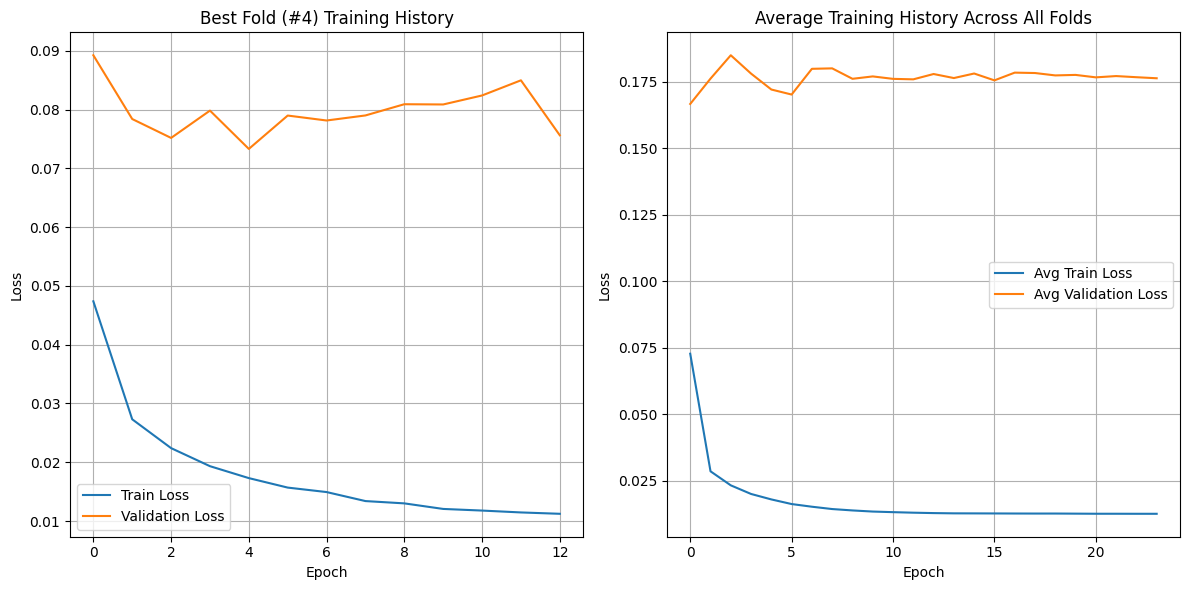

Model Performance Comparison:
Original VIVE vs Vicon:
  RMSE: 103.8633
  MAE:  75.2352

Ensemble Model vs Vicon:
  RMSE: 8.2380
  MAE:  6.3219

Improvement:
  RMSE: +92.07% (Better)
  MAE:  +91.60% (Better)


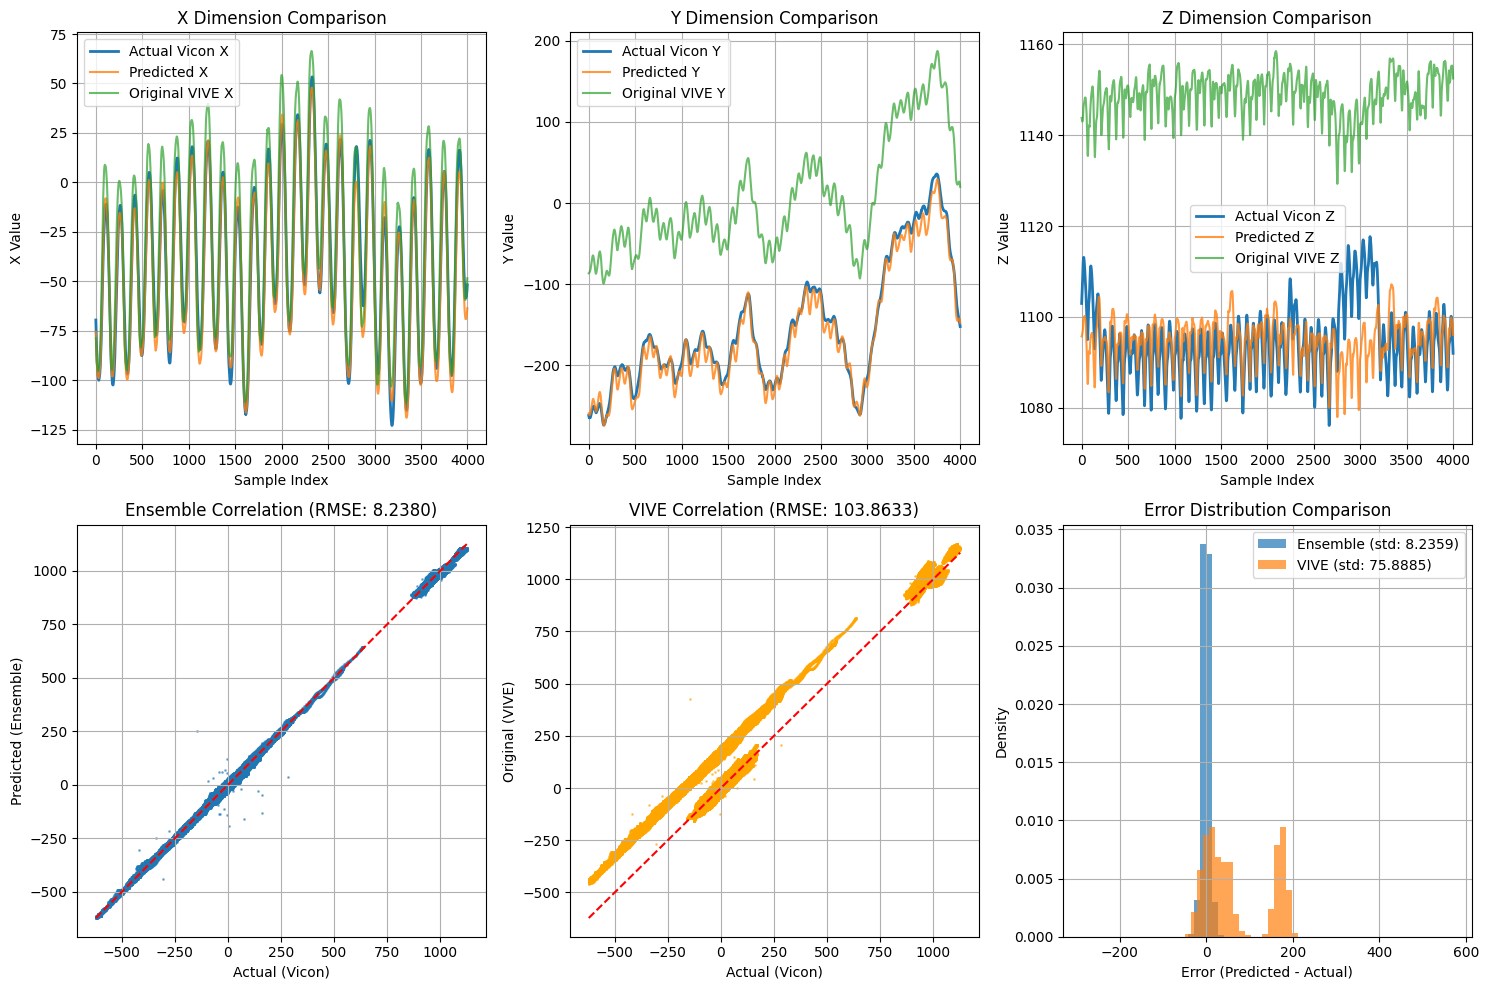


Detailed Error Statistics:
Ensemble Model Errors:
  Mean Error: -0.1856
  Std Error:  8.2359
  Min Error:  -287.6443
  Max Error:  396.8817

Original VIVE Errors:
  Mean Error: 70.9121
  Std Error:  75.8885
  Min Error:  -117.5438
  Max Error:  570.4834

Per-Dimension RMSE:
X Dimension:
  VIVE RMSE:     18.6566
  Ensemble RMSE: 9.3001
  Improvement:   +50.15%
Y Dimension:
  VIVE RMSE:     173.7420
  Ensemble RMSE: 7.2882
  Improvement:   +95.81%
Z Dimension:
  VIVE RMSE:     42.7601
  Ensemble RMSE: 7.9991
  Improvement:   +81.29%
Best model saved to 'best_vive_to_vicon_CoM_model.pth'


In [ ]:
# Initialise the final model with the best weights
final_model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)
final_model.load_state_dict(best_models[best_fold_idx])

# Plot training history for the best fold
best_history = all_histories[best_fold_idx]
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(best_history['train_loss'], label='Train Loss')
plt.plot(best_history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Best Fold (#{best_fold_idx+1}) Training History')
plt.legend()
plt.grid(True)

# Plot average training history across all folds
plt.subplot(1, 2, 2)
max_epochs = max(len(h['train_loss']) for h in all_histories)
padded_train_losses = []
padded_val_losses = []

for h in all_histories:
    train_loss = h['train_loss'] + [h['train_loss'][-1]] * (max_epochs - len(h['train_loss']))
    val_loss = h['val_loss'] + [h['val_loss'][-1]] * (max_epochs - len(h['val_loss']))
    
    padded_train_losses.append(train_loss)
    padded_val_losses.append(val_loss)

avg_train_loss = np.mean(padded_train_losses, axis=0)
avg_val_loss = np.mean(padded_val_losses, axis=0)

plt.plot(avg_train_loss, label='Avg Train Loss')
plt.plot(avg_val_loss, label='Avg Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Average Training History Across All Folds')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Ensemble prediction function (using all trained models)
def ensemble_predict(models, X_time_test, X_feat_test, batch_size=64):
    predictions = []
    
    # Create test dataset
    test_dataset = TensorDataset(
        torch.tensor(X_time_test, dtype=torch.float32),
        torch.tensor(X_feat_test, dtype=torch.float32)
    )
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # Predict with each model
    for model_state in models:
        model = AdvancedTransformerModel(seq_length, num_features=X_feat.shape[1]).to(device)
        model.load_state_dict(model_state)
        model.eval()
        
        fold_preds = []
        with torch.no_grad():
            for batch_X_time, batch_X_feat in test_loader:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                
                output = model(batch_X_time, batch_X_feat)
                fold_preds.append(output.cpu().numpy())
                
                # Free memory
                del batch_X_time, batch_X_feat, output
        
        # Concatenate predictions for this fold
        fold_preds = np.vstack(fold_preds)
        predictions.append(fold_preds)
    
    # Average predictions from all models
    ensemble_predictions = np.mean(predictions, axis=0)
    
    return ensemble_predictions

# Function to evaluate on the entire dataset using the ensemble
def evaluate_ensemble(models, X_time, X_feat, y, batch_size=64):
    # Get ensemble predictions
    predictions = ensemble_predict(models, X_time, X_feat, batch_size)
    
    # Inverse transform predictions and targets back to original scale
    # Updated to use the scalers dictionary
    predictions = scalers['vicon_xyz'].inverse_transform(predictions)
    
    # For VIVE original, we need to inverse transform the last timestep of X_time
    # X_time contains scaled VIVE XYZ data, so we use vive_xyz scaler
    vive_original = scalers['vive_xyz'].inverse_transform(X_time[:, -1])  # Shape: (samples, 3)
    
    # Inverse transform target y
    y_original = scalers['vicon_xyz'].inverse_transform(y)
    
    # Calculate metrics for Ensemble vs Vicon
    ensemble_mse = np.mean((predictions - y_original) ** 2)
    ensemble_rmse = np.sqrt(ensemble_mse)
    ensemble_mae = np.mean(np.abs(predictions - y_original))
    
    # Calculate metrics for Original VIVE vs Vicon
    vive_mse = np.mean((vive_original - y_original) ** 2)
    vive_rmse = np.sqrt(vive_mse)
    vive_mae = np.mean(np.abs(vive_original - y_original))
    
    # Calculate improvement
    rmse_improvement = ((vive_rmse - ensemble_rmse) / vive_rmse) * 100
    mae_improvement = ((vive_mae - ensemble_mae) / vive_mae) * 100
    
    print(f"Model Performance Comparison:")
    print(f"{'='*50}")
    print(f"Original VIVE vs Vicon:")
    print(f"  RMSE: {vive_rmse:.4f}")
    print(f"  MAE:  {vive_mae:.4f}")
    print(f"")
    print(f"Ensemble Model vs Vicon:")
    print(f"  RMSE: {ensemble_rmse:.4f}")
    print(f"  MAE:  {ensemble_mae:.4f}")
    print(f"")
    print(f"Improvement:")
    print(f"  RMSE: {rmse_improvement:+.2f}% {'(Better)' if rmse_improvement > 0 else '(Worse)'}")
    print(f"  MAE:  {mae_improvement:+.2f}% {'(Better)' if mae_improvement > 0 else '(Worse)'}")
    
    # Visualize predictions vs actual
    plt.figure(figsize=(15, 10))
    
    # Plot a sample of the data (first 4000 points)
    sample_size = min(4000, len(predictions))
    
    # Time series comparison - show each XYZ dimension
    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(2, 3, i+1)
        plt.plot(y_original[:sample_size, i], label=f'Actual Vicon {dim}', linewidth=2)
        plt.plot(predictions[:sample_size, i], label=f'Predicted {dim}', alpha=0.8)
        plt.plot(vive_original[:sample_size, i], label=f'Original VIVE {dim}', alpha=0.7)
        plt.xlabel('Sample Index')
        plt.ylabel(f'{dim} Value')
        plt.title(f'{dim} Dimension Comparison')
        plt.legend()
        plt.grid(True)
    
    # Overall correlation plot for Ensemble
    plt.subplot(2, 3, 4)
    plt.scatter(y_original.flatten(), predictions.flatten(), alpha=0.5, s=1)
    plt.plot([y_original.min(), y_original.max()], [y_original.min(), y_original.max()], 'r--')
    plt.xlabel('Actual (Vicon)')
    plt.ylabel('Predicted (Ensemble)')
    plt.title(f'Ensemble Correlation (RMSE: {ensemble_rmse:.4f})')
    plt.grid(True)
    
    # Overall correlation plot for Original VIVE
    plt.subplot(2, 3, 5)
    plt.scatter(y_original.flatten(), vive_original.flatten(), alpha=0.5, s=1, color='orange')
    plt.plot([y_original.min(), y_original.max()], [y_original.min(), y_original.max()], 'r--')
    plt.xlabel('Actual (Vicon)')
    plt.ylabel('Original (VIVE)')
    plt.title(f'VIVE Correlation (RMSE: {vive_rmse:.4f})')
    plt.grid(True)
    
    # Error distribution comparison
    plt.subplot(2, 3, 6)
    ensemble_errors = predictions.flatten() - y_original.flatten()
    vive_errors = vive_original.flatten() - y_original.flatten()
    
    plt.hist(ensemble_errors, bins=50, alpha=0.7, label=f'Ensemble (std: {np.std(ensemble_errors):.4f})', density=True)
    plt.hist(vive_errors, bins=50, alpha=0.7, label=f'VIVE (std: {np.std(vive_errors):.4f})', density=True)
    plt.xlabel('Error (Predicted - Actual)')
    plt.ylabel('Density')
    plt.title('Error Distribution Comparison')
    plt.legend()
    plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed statistics
    print(f"\nDetailed Error Statistics:")
    print(f"{'='*50}")
    print(f"Ensemble Model Errors:")
    print(f"  Mean Error: {np.mean(ensemble_errors):.4f}")
    print(f"  Std Error:  {np.std(ensemble_errors):.4f}")
    print(f"  Min Error:  {np.min(ensemble_errors):.4f}")
    print(f"  Max Error:  {np.max(ensemble_errors):.4f}")
    print(f"")
    print(f"Original VIVE Errors:")
    print(f"  Mean Error: {np.mean(vive_errors):.4f}")
    print(f"  Std Error:  {np.std(vive_errors):.4f}")
    print(f"  Min Error:  {np.min(vive_errors):.4f}")
    print(f"  Max Error:  {np.max(vive_errors):.4f}")
    
    # Print per-dimension statistics
    print(f"\nPer-Dimension RMSE:")
    print(f"{'='*30}")
    for i, dim in enumerate(['X', 'Y', 'Z']):
        ensemble_rmse_dim = np.sqrt(np.mean((predictions[:, i] - y_original[:, i]) ** 2))
        vive_rmse_dim = np.sqrt(np.mean((vive_original[:, i] - y_original[:, i]) ** 2))
        improvement_dim = ((vive_rmse_dim - ensemble_rmse_dim) / vive_rmse_dim) * 100
        
        print(f"{dim} Dimension:")
        print(f"  VIVE RMSE:     {vive_rmse_dim:.4f}")
        print(f"  Ensemble RMSE: {ensemble_rmse_dim:.4f}")
        print(f"  Improvement:   {improvement_dim:+.2f}%")
    
    return predictions, y_original, vive_original

# Evaluate the ensemble on the entire dataset
predictions, actuals, vive_original = evaluate_ensemble(best_models, X_time, X_feat, y)

# Save the best model
torch.save(final_model.state_dict(), 'best_vive_to_vicon_CoM_model.pth')
print("Best model saved to 'best_vive_to_vicon_CoM_model.pth'")

# Feature importance analysis
def analyze_feature_importance(model, X_time, X_feat, y, feature_names):
    # Base performance
    model.eval()
    base_preds = []
    
    # Create dataset
    dataset = TensorDataset(
        torch.tensor(X_time, dtype=torch.float32),
        torch.tensor(X_feat, dtype=torch.float32)
    )
    data_loader = DataLoader(dataset, batch_size=64, shuffle=False)
    
    with torch.no_grad():
        for batch_X_time, batch_X_feat in data_loader:
            batch_X_time = batch_X_time.to(device)
            batch_X_feat = batch_X_feat.to(device)
            
            output = model(batch_X_time, batch_X_feat)
            base_preds.append(output.cpu().numpy())
    
    base_preds = np.vstack(base_preds)
    base_mse = np.mean((base_preds - y) ** 2)  # Updated: y is now 3D (samples, 3)
    
    # Permutation importance
    importance_scores = []
    
    for i in range(X_feat.shape[1]):
        # Create a copy and permute one feature
        X_feat_permuted = X_feat.copy()
        X_feat_permuted[:, i] = np.random.permutation(X_feat_permuted[:, i])
        
        # Predict with permuted feature
        perm_preds = []
        
        dataset_perm = TensorDataset(
            torch.tensor(X_time, dtype=torch.float32),
            torch.tensor(X_feat_permuted, dtype=torch.float32)
        )
        loader_perm = DataLoader(dataset_perm, batch_size=64, shuffle=False)
        
        with torch.no_grad():
            for batch_X_time, batch_X_feat in loader_perm:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                
                output = model(batch_X_time, batch_X_feat)
                perm_preds.append(output.cpu().numpy())
        
        perm_preds = np.vstack(perm_preds)
        perm_mse = np.mean((perm_preds - y) ** 2)  # Updated: y is now 3D (samples, 3)
        
        # Importance is the increase in error
        importance = perm_mse - base_mse
        importance_scores.append(importance)
    
    # Visualise feature importance
    plt.figure(figsize=(12, 8))
    sorted_idx = np.argsort(importance_scores)
    plt.barh(range(len(feature_names)), [importance_scores[i] for i in sorted_idx])
    plt.yticks(range(len(feature_names)), [feature_names[i] for i in sorted_idx])
    plt.xlabel('Increase in MSE when feature is permuted')
    plt.title('Feature Importance Analysis')
    plt.grid(True, axis='x')
    plt.tight_layout()
    plt.show()
    
    return importance_scores

# Define feature names for visualization (updated to match new 7 features)
feature_names = [
    'Speed', 
    'Hip Thickness', 
    'VIVE Spatial Magnitude', 
    'VIVE X Velocity', 
    'VIVE Y Velocity', 
    'VIVE Z Velocity'
]

# Verify feature count matches
assert len(feature_names) == X_feat.shape[1], f"Feature names count ({len(feature_names)}) doesn't match actual features ({X_feat.shape[1]})"

# Analyze feature importance
importance_scores = analyze_feature_importance(final_model, X_time, X_feat, y, feature_names)
print("Feature importance analysis complete!")

# Function to save ensemble models
def save_ensemble_models(models, model_dir='saved_models'):
    """
    Save all models in the ensemble to disk
    
    Parameters:
    -----------
    models : list
        List of model state dictionaries
    model_dir : str
        Directory to save models in
    
    Returns:
    --------
    model_path : str
        Path to the saved ensemble
    """
    # Create directory if it doesn't exist
    os.makedirs(model_dir, exist_ok=True)
    
    # Create timestamp for unique filename
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    ensemble_path = os.path.join(model_dir, f"vive_vicon_CoM_ensemble_{timestamp}")
    os.makedirs(ensemble_path, exist_ok=True)
    
    # Save each model in the ensemble
    for i, model_state in enumerate(models):
        model_path = os.path.join(ensemble_path, f"model_fold_{i+1}.pth")
        torch.save(model_state, model_path)
    

# Updated ensemble models data structure
ensemble_models_data = {
    'model_states': best_models,
    'model_config': {
        'seq_length': seq_length,
        'num_features': X_feat.shape[1]  # Now 7 features
    },
    'preprocessing': {
        'scalers': scalers,  # Dictionary containing all scalers
        'participant_encoder': participant_encoder,
        'hip_thickness': hip_thickness
    }
}

# Save ensemble model
with open('ensemble_models.pkl', 'wb') as f:
    pickle.dump(ensemble_models_data, f)
print("Ensemble model has been saved to 'ensemble_models.pkl'")

In [ ]:
def load_ensemble_models():
    with open('ensemble_models.pkl', 'rb') as f:
        ensemble_data = pickle.load(f)
    return ensemble_data

# Integrated prediction function
def ensemble_predict_custom(start_index, length, X_time, X_feat, y):
    # Load ensemble model data
    ensemble_data = load_ensemble_models()
    
    # Validate index range
    end_index = min(start_index + length, len(X_time))
    if start_index >= len(X_time) or start_index < 0:
        print(f"Error: Start index out of range [0, {len(X_time)-1}]")
        return None
    
    # Extract data
    X_time_subset = X_time[start_index:end_index]
    X_feat_subset = X_feat[start_index:end_index]
    y_subset = y[start_index:end_index]
    
    # Create data loader
    test_dataset = TensorDataset(
        torch.tensor(X_time_subset, dtype=torch.float32),
        torch.tensor(X_feat_subset, dtype=torch.float32)
    )
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)
    
    # Make predictions using all models
    all_predictions = []
    
    for model_state in ensemble_data['model_states']:
        model = AdvancedTransformerModel(
            ensemble_data['model_config']['seq_length'],
            num_features=ensemble_data['model_config']['num_features']
        ).to(device)
        model.load_state_dict(model_state)
        model.eval()
        
        fold_preds = []
        with torch.no_grad():
            for batch_X_time, batch_X_feat in test_loader:
                batch_X_time = batch_X_time.to(device)
                batch_X_feat = batch_X_feat.to(device)
                output = model(batch_X_time, batch_X_feat)
                fold_preds.append(output.cpu().numpy())
        
        fold_preds = np.vstack(fold_preds)
        all_predictions.append(fold_preds)
    
    # Average prediction results
    ensemble_predictions = np.mean(all_predictions, axis=0)
    
    # Inverse normalization - Updated to use scalers dictionary
    scalers = ensemble_data['preprocessing']['scalers']
    
    predictions_original = scalers['vicon_xyz'].inverse_transform(ensemble_predictions)
    y_original = scalers['vicon_xyz'].inverse_transform(y_subset)
    vive_original = scalers['vive_xyz'].inverse_transform(X_time_subset[:, -1])
    
    # Calculate evaluation metrics
    ensemble_mse = np.mean((predictions_original - y_original) ** 2)
    ensemble_rmse = np.sqrt(ensemble_mse)
    ensemble_mae = np.mean(np.abs(predictions_original - y_original))
    
    vive_mse = np.mean((vive_original - y_original) ** 2)
    vive_rmse = np.sqrt(vive_mse)
    vive_mae = np.mean(np.abs(vive_original - y_original))
    
    rmse_improvement = ((vive_rmse - ensemble_rmse) / vive_rmse) * 100
    mae_improvement = ((vive_mae - ensemble_mae) / vive_mae) * 100
    
    print(f"Prediction results for index range {start_index}-{end_index-1}:")
    print(f"Original VIVE vs Vicon: RMSE={vive_rmse:.4f}, MAE={vive_mae:.4f}")
    print(f"Ensemble model vs Vicon: RMSE={ensemble_rmse:.4f}, MAE={ensemble_mae:.4f}")
    print(f"Improvement: RMSE {rmse_improvement:+.2f}%, MAE {mae_improvement:+.2f}%")
    
    # Visualization - Updated for 3D XYZ data
    sample_size = min(2000, len(predictions_original))
    
    plt.figure(figsize=(15, 12))
    
    # Plot each XYZ dimension separately
    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(3, 2, i*2+1)
        plt.plot(y_original[:sample_size, i], label=f'Actual Vicon {dim}', linewidth=2)
        plt.plot(predictions_original[:sample_size, i], label=f'Predicted {dim}', alpha=0.8)
        plt.plot(vive_original[:sample_size, i], label=f'Original VIVE {dim}', alpha=0.7)
        plt.xlabel('Sample Index')
        plt.ylabel(f'{dim} Value')
        plt.title(f'{dim} Dimension Time Series')
        plt.legend()
        plt.grid(True)
        
        plt.subplot(3, 2, i*2+2)
        plt.scatter(y_original[:sample_size, i], predictions_original[:sample_size, i], 
                   alpha=0.5, s=1, label='Ensemble')
        plt.scatter(y_original[:sample_size, i], vive_original[:sample_size, i], 
                   alpha=0.5, s=1, color='orange', label='VIVE')
        plt.plot([y_original[:sample_size, i].min(), y_original[:sample_size, i].max()], 
                [y_original[:sample_size, i].min(), y_original[:sample_size, i].max()], 'r--')
        plt.xlabel(f'Actual Vicon {dim}')
        plt.ylabel(f'Predicted {dim}')
        plt.title(f'{dim} Dimension Correlation')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Overall error distribution
    plt.figure(figsize=(12, 4))
    
    for i, dim in enumerate(['X', 'Y', 'Z']):
        plt.subplot(1, 3, i+1)
        ensemble_errors = predictions_original[:, i] - y_original[:, i]
        vive_errors = vive_original[:, i] - y_original[:, i]
        
        plt.hist(ensemble_errors, bins=30, alpha=0.7, 
                label=f'Ensemble (std: {np.std(ensemble_errors):.4f})', density=True)
        plt.hist(vive_errors, bins=30, alpha=0.7, 
                label=f'VIVE (std: {np.std(vive_errors):.4f})', density=True)
        plt.xlabel(f'{dim} Error')
        plt.ylabel('Density')
        plt.title(f'{dim} Error Distribution')
        plt.legend()
        plt.grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Print per-dimension statistics
    print(f"\nPer-Dimension Statistics:")
    print(f"{'='*40}")
    for i, dim in enumerate(['X', 'Y', 'Z']):
        ensemble_rmse_dim = np.sqrt(np.mean((predictions_original[:, i] - y_original[:, i]) ** 2))
        vive_rmse_dim = np.sqrt(np.mean((vive_original[:, i] - y_original[:, i]) ** 2))
        improvement_dim = ((vive_rmse_dim - ensemble_rmse_dim) / vive_rmse_dim) * 100
        
        print(f"{dim} Dimension:")
        print(f"  VIVE RMSE:     {vive_rmse_dim:.4f}")
        print(f"  Ensemble RMSE: {ensemble_rmse_dim:.4f}")
        print(f"  Improvement:   {improvement_dim:+.2f}%")
    
    return predictions_original, y_original, vive_original

# Test the prediction function
predictions, actual, vive = ensemble_predict_custom(
    start_index=20001,    # Starting position
    length=5000,         # Number of prediction samples
    X_time=X_time,       # Time features
    X_feat=X_feat,       # Other features
    y=y                  # Ground truth labels
)